# This demo shows how to obtain valid data for mpc.


In [1]:
import matplotlib.pyplot as plt
from matplotlib.pylab import mpl
import numpy as np
import pandas as pd
from Influxdb_API.Influxdb_API import ClientInfluxdb
import preprocess

## 1. Get orignal data by influxdb_API

In [2]:
data_required = {
    'moserveribms': {
        'ibmsV2modata': {
            'tag_dict': {'nid': 'ibmsv2/ibmsv2_5929149262402256896/EMeter/mDev_EMeter_Roof_MDV_10'},
            'field_list': ['E']
        },
        'bridgemodata': {
            'tag_dict': {'nid': 'ibms/ibms_1564376390869024768/microWeatherStation/20201800'},
            'field_list': ['e3']
        }
    },
    'moserver': {
        'modata': {
            'tag_dict': {'nid': 'vrf/vrf_0000CC311178CCM26232341000271K0V/indoor/0'},
            'field_list': ['roomTemp']
        }
    },
}

df_list = []
for key1, value1 in data_required.items():
    for key2, value2 in value1.items():
            db_name_temp = key1
            params_temp = {
                'measurement_name': key2,
                'start_time': pd.to_datetime('2022-07-01 00:00:00'),
                'end_time': pd.to_datetime('2022-11-01 00:00:00'),
                'field_list': value2['field_list'],
                'tag_dict': value2['tag_dict'],
                'fore': False,
                'fore_horizon': None,
                'interval': None
            }
            db_client_temp = ClientInfluxdb(db_name=db_name_temp) 
            df_temp = db_client_temp.read_influxdb(**params_temp)
            # str -> np.float64
            for col in df_temp.columns:
                df_temp[col] = pd.to_numeric(df_temp[col], errors='ignore')
            # resampling data, rsp_time=15min, 如果是启停等离散数据重采样不能mean(), 需要修改
            df_temp = df_temp.resample('15 min').mean()
            df_list.append(df_temp)

data = pd.concat(df_list, axis=1)

#### Recommended to interpolate the meter data before differencing

In [3]:
data['E'], _ = preprocess.od_boxplot(data['E'].to_frame(), win_size=4*24*3, remove_outlier=True)
data['E'] = preprocess.impute_linear(data['E'].to_frame(), pd.Timedelta('15 min'), pd.Timedelta('12 hour'))
data['E'] = data['E'].diff()
data

,E,e3,roomTemp
2022-07-01 00:00:00,NaN,27.500000,30.344444
2022-07-01 00:15:00,0.21,27.266667,30.481818
2022-07-01 00:30:00,0.00,26.966667,30.618182
2022-07-01 00:45:00,0.19,26.900000,30.700000
2022-07-01 01:00:00,0.00,27.033333,30.700000
...,...,...,...
2022-10-31 22:45:00,0.00,24.500000,NaN
2022-10-31 23:00:00,0.01,NaN,NaN
2022-10-31 23:15:00,0.00,24.400000,NaN
2022-10-31 23:30:00,0.00,NaN,NaN


## 2. Preprocess data

In [4]:
params = {
    # common parameters
    'sampling_time': pd.Timedelta('15 min'),
    'sampling_rate': 4,   # 4 times per hour, depends on sampling_time.

    # parameters of remove outliers
    'win_size_boxplot': 4*24*7,   # win_size_boxplot=sampling_rate/h*24h/day*7day, time window size of remove outliers by boxplot.
    'win_size_sigma': 4*24*60,   # win_size_sigma=sampling_rate/h*24h/day*60day, time window size of remove outliers by 3-sigma.
    # parameters of data imputation
    'linear_time_delta': pd.Timedelta('4 hours'),   # data missing for more than consecutive linear_time_delta will not be linear imputation.

    # parameters of obtain valid data (by calculating missing rate)
    'ms_thresh': 0.0,   # the condition of missing rate (< ms_thresh) for multiple data.
    'interval_min_day': 2,   # minimum number of days needed for training.
    'interval_max_day': 10,   # maximum number of days needed for training.
    # 'gap_max': pd.Timedelta('4 hours'),
}

column_type = {
    'E': 'Meter',
    'e3': 'T_amb',
    'roomTemp': 'T_amb'
}

prepro = preprocess.DataPreprocess(data=data, column_type=column_type, **params)
prepro.process(oldt_method=None, impute_method=None)

## 3. Obtain valid data by calculating missing rate range(interval_max_day, interval_min_day) days backward at each sampling point

E imputation, the closest optimal moment to the present:  2022-07-17 06:00:00 (minimum missing rate: 0.0) 
------------------
e3 imputation, the closest optimal moment to the present:  2022-10-31 23:45:00 (minimum missing rate: 0.0) 
------------------
roomTemp imputation, the closest optimal moment to the present:  2022-10-06 22:15:00 (minimum missing rate: 0.0) 
------------------
imputation, the closest moment meets the condition (missing rate <= 0.0, 10.0 days) for multiple data:  2022-07-12 18:45:00 
------------------




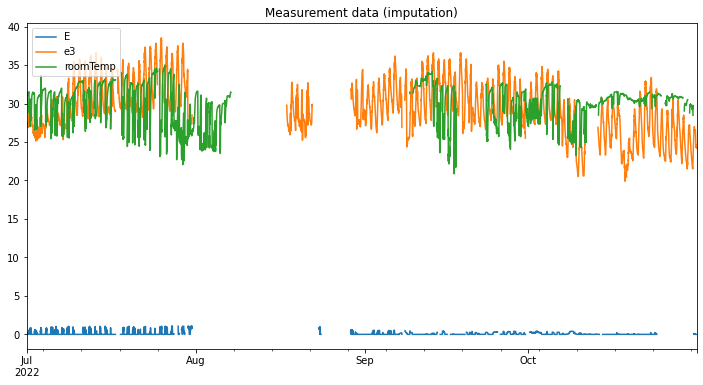

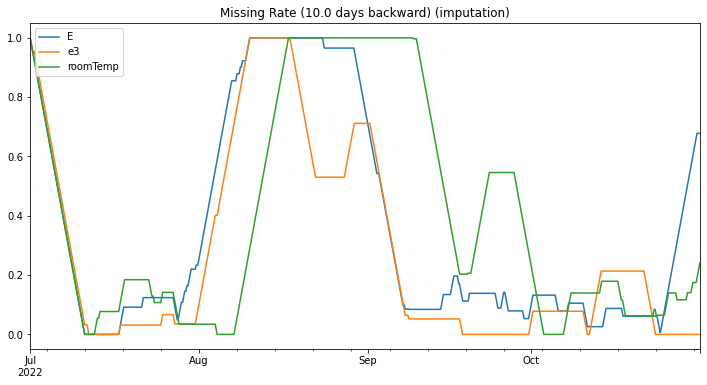

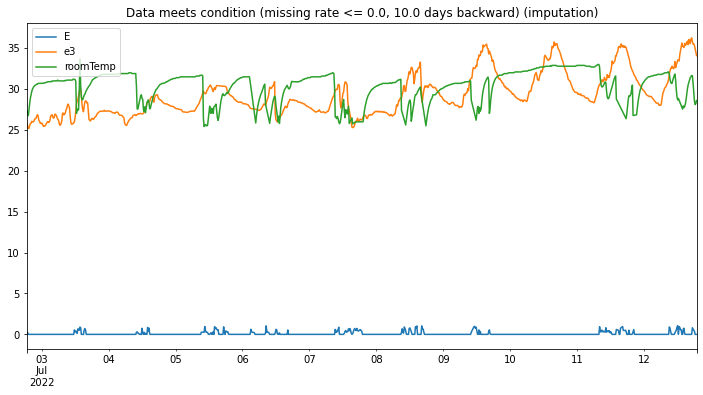

In [5]:
data_valid = preprocess.valid_data(prepro.data_impute, label='imputation', plot=True, **params)